In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv("../data/European_Bank_Processed.csv")

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditScoreBand,TenureGroup,BalanceSegment,EngagementStatus
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,30-45,Medium,New,Zero-balance,Active
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,30-45,Medium,New,Low-balance,Active
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-45,Low,Long-term,High-balance,Inactive
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,30-45,Medium,New,Zero-balance,Inactive
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30-45,High,New,High-balance,Active


In [16]:
high_value_df = df[
    df["BalanceSegment"] == "High-balance"
].copy()

high_value_df.shape

(5000, 16)

In [17]:
high_value_df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditScoreBand,TenureGroup,BalanceSegment,EngagementStatus
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,30-45,Low,Long-term,High-balance,Inactive
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,30-45,High,New,High-balance,Active
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,30-45,Medium,Long-term,High-balance,Inactive
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,<30,Low,Mid-term,High-balance,Inactive
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,30-45,Low,Mid-term,High-balance,Active


High value customer overview

In [18]:
total_high_value = len(high_value_df)

high_value_churners = high_value_df["Exited"].sum()

high_value_retained = (
    total_high_value - high_value_churners
)

high_value_churn_rate = (
    high_value_churners / total_high_value * 100
)

high_value_retention_rate = (
    high_value_retained / total_high_value * 100
)

print("Total High-Value Customers:", total_high_value)
print("High-Value Churners:", high_value_churners)
print("High-Value Retained:", high_value_retained)
print("High-Value Churn Rate:", round(high_value_churn_rate, 2), "%")
print("High-Value Retention Rate:", round(high_value_retention_rate, 2), "%")

Total High-Value Customers: 5000
High-Value Churners: 1249
High-Value Retained: 3751
High-Value Churn Rate: 24.98 %
High-Value Retention Rate: 75.02 %


Financial exposure

In [19]:
high_value_churned_df = high_value_df[
    high_value_df["Exited"] == 1
].copy()

high_value_churned_df.shape

(1249, 16)

In [20]:
total_exposure = high_value_churned_df["Balance"].sum()

average_exposure = high_value_churned_df["Balance"].mean()

median_exposure = high_value_churned_df["Balance"].median()

maximum_exposure = high_value_churned_df["Balance"].max()

print("Total Financial Exposure:", round(total_exposure, 2))
print("Average Balance:", round(average_exposure, 2))
print("Median Balance:", round(median_exposure, 2))
print("Maximum Balance:", round(maximum_exposure, 2))

Total Financial Exposure: 163242872.31
Average Balance: 130698.86
Median Balance: 126397.66
Maximum Balance: 250898.09


High-Value Churn by Geography 

In [21]:
hv_geo_churn = (
    high_value_df
    .groupby("Geography")["Exited"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

hv_geo_churn["ChurnRate"] = (
    hv_geo_churn["mean"] * 100
)

hv_geo_churn["ChurnContribution"] = (
    hv_geo_churn["sum"]
    / high_value_churners
    * 100
)

hv_geo_churn = hv_geo_churn.drop(columns="mean")

hv_geo_churn

,Geography,count,sum,ChurnRate,ChurnContribution
0,France,1986,353,17.774421,28.262610
1,Germany,2042,728,35.651322,58.286629
2,Spain,972,168,17.283951,13.450761


Financial Exposure by Geography

In [22]:
hv_geo_exposure = (
    high_value_churned_df
    .groupby("Geography")["Balance"]
    .agg(["count", "sum", "mean", "median"])
    .reset_index()
)

hv_geo_exposure.columns = [
    "Geography",
    "Churners",
    "TotalExposure",
    "AverageBalance",
    "MedianBalance"
]

hv_geo_exposure

,Geography,Churners,TotalExposure,AverageBalance,MedianBalance
0,France,353,48973245.01,138734.405127,134264.040
1,Germany,728,90432687.90,124220.725137,121658.735
2,Spain,168,23836939.40,141886.544048,135426.645


High-Value Churn by Age

In [23]:
hv_age_churn = (
    high_value_df
    .groupby("AgeGroup")["Exited"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

hv_age_churn["ChurnRate"] = (
    hv_age_churn["mean"] * 100
)

hv_age_churn["ChurnContribution"] = (
    hv_age_churn["sum"]
    / high_value_churners
    * 100
)

hv_age_churn = hv_age_churn.drop(columns="mean")

hv_age_churn.sort_values(
    "ChurnRate",
    ascending=False
)

,AgeGroup,count,sum,ChurnRate,ChurnContribution
1,46-60,879,505,57.451650,40.432346
2,60+,229,70,30.567686,5.604484
0,30-45,3103,589,18.981631,47.157726
3,<30,789,85,10.773131,6.805444


High-Value Churn by Engagement

In [24]:
hv_engagement_churn = (
    high_value_df
    .groupby("EngagementStatus")["Exited"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

hv_engagement_churn["ChurnRate"] = (
    hv_engagement_churn["mean"] * 100
)

hv_engagement_churn["ChurnContribution"] = (
    hv_engagement_churn["sum"]
    / high_value_churners
    * 100
)

hv_engagement_churn = hv_engagement_churn.drop(columns="mean")

hv_engagement_churn

,EngagementStatus,count,sum,ChurnRate,ChurnContribution
0,Active,2544,455,17.88522,36.429143
1,Inactive,2456,794,32.32899,63.570857


High-Value Risk Profile

In [25]:
hv_risk_profile = (
    high_value_df
    .groupby(
        [
            "Geography",
            "AgeGroup",
            "EngagementStatus"
        ]
    )["Exited"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

hv_risk_profile["ChurnRate"] = (
    hv_risk_profile["mean"] * 100
)

hv_risk_profile["ChurnContribution"] = (
    hv_risk_profile["sum"]
    / high_value_churners
    * 100
)

hv_risk_profile = hv_risk_profile.drop(columns="mean")

hv_risk_profile = hv_risk_profile.sort_values(
    "ChurnRate",
    ascending=False
)

hv_risk_profile

,Geography,AgeGroup,EngagementStatus,count,sum,ChurnRate,ChurnContribution
5,France,60+,Inactive,15,15,100.000000,1.200961
11,Germany,46-60,Inactive,237,195,82.278481,15.612490
13,Germany,60+,Inactive,26,21,80.769231,1.681345
21,Spain,60+,Inactive,7,5,71.428571,0.400320
19,Spain,46-60,Inactive,64,40,62.500000,3.202562
3,France,46-60,Inactive,144,87,60.416667,6.965572
10,Germany,46-60,Active,195,105,53.846154,8.406725
2,France,46-60,Active,144,51,35.416667,4.083267
9,Germany,30-45,Inactive,616,212,34.415584,16.973579
18,Spain,46-60,Active,95,27,28.421053,2.161729


In [26]:
reliable_hv_risk_profile = hv_risk_profile[
    hv_risk_profile["count"] >= 50
].copy()

reliable_hv_risk_profile.head(15)

,Geography,AgeGroup,EngagementStatus,count,sum,ChurnRate,ChurnContribution
11,Germany,46-60,Inactive,237,195,82.278481,15.612490
19,Spain,46-60,Inactive,64,40,62.500000,3.202562
3,France,46-60,Inactive,144,87,60.416667,6.965572
10,Germany,46-60,Active,195,105,53.846154,8.406725
2,France,46-60,Active,144,51,35.416667,4.083267
9,Germany,30-45,Inactive,616,212,34.415584,16.973579
18,Spain,46-60,Active,95,27,28.421053,2.161729
12,Germany,60+,Active,65,17,26.153846,1.361089
8,Germany,30-45,Active,604,134,22.185430,10.728583
15,Germany,<30,Inactive,151,32,21.192053,2.562050


Salary vs Balance

In [27]:
hv_salary_balance = (
    high_value_df
    .groupby("Exited")[
        ["EstimatedSalary", "Balance"]
    ]
    .agg(["mean", "median"])
)

hv_salary_balance.index = [
    "Retained",
    "Churned"
]

hv_salary_balance.round(2)

EstimatedSalary               Balance           
                    mean     median       mean     median
Retained       100748.01  100687.67  131144.50  128029.72
Churned        100203.65  101240.08  130698.86  126397.66

In [28]:
retained_salary = high_value_df.loc[
    high_value_df["Exited"] == 0,
    "EstimatedSalary"
].mean()

churned_salary = high_value_df.loc[
    high_value_df["Exited"] == 1,
    "EstimatedSalary"
].mean()

salary_difference = churned_salary - retained_salary

print("Retained Average Salary:", round(retained_salary, 2))
print("Churned Average Salary:", round(churned_salary, 2))
print("Salary Difference:", round(salary_difference, 2))

Retained Average Salary: 100748.01
Churned Average Salary: 100203.65
Salary Difference: -544.36


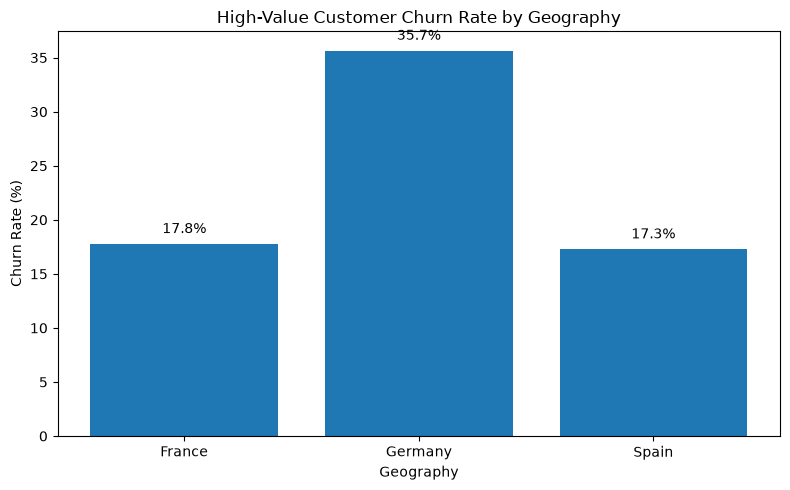

In [29]:
plt.figure(figsize=(8, 5))

plt.bar(
    hv_geo_churn["Geography"],
    hv_geo_churn["ChurnRate"]
)

plt.title("High-Value Customer Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(hv_geo_churn["ChurnRate"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/high_value_churn_by_geography.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

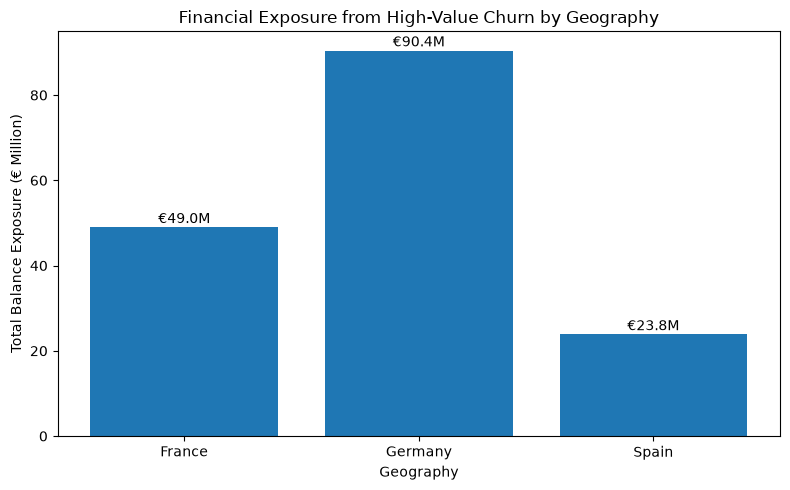

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    hv_geo_exposure["Geography"],
    hv_geo_exposure["TotalExposure"] / 1_000_000
)

plt.title("Financial Exposure from High-Value Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Total Balance Exposure (€ Million)")

for i, value in enumerate(
    hv_geo_exposure["TotalExposure"] / 1_000_000
):
    plt.text(
        i,
        value + 1,
        f"€{value:.1f}M",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/high_value_financial_exposure_by_geography.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

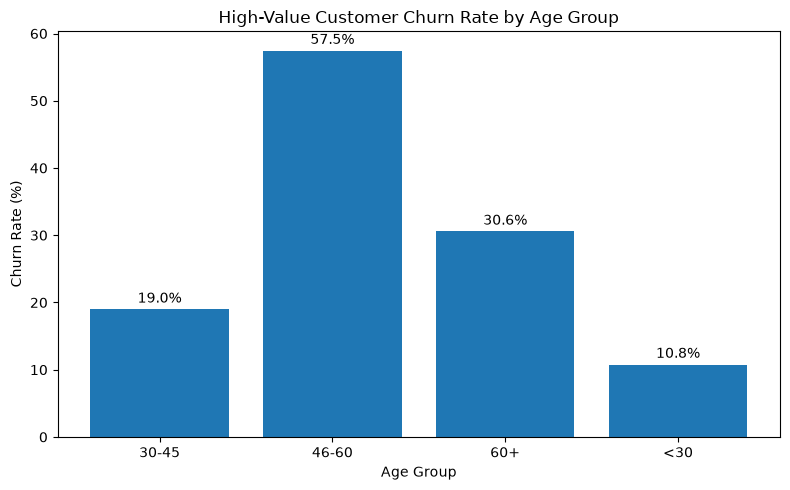

In [31]:
hv_age_plot = hv_age_churn.sort_values(
    "AgeGroup"
)

plt.figure(figsize=(8, 5))

plt.bar(
    hv_age_plot["AgeGroup"],
    hv_age_plot["ChurnRate"]
)

plt.title("High-Value Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(hv_age_plot["ChurnRate"]):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/high_value_churn_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


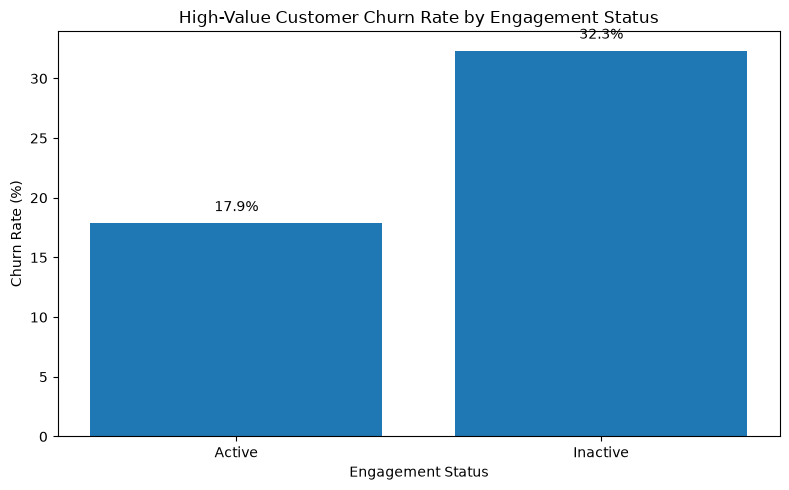

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    hv_engagement_churn["EngagementStatus"],
    hv_engagement_churn["ChurnRate"]
)

plt.title("High-Value Customer Churn Rate by Engagement Status")
plt.xlabel("Engagement Status")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(
    hv_engagement_churn["ChurnRate"]
):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/high_value_churn_by_engagement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
top_hv_risk = (
    reliable_hv_risk_profile
    .head(10)
    .copy()
)

top_hv_risk["Segment"] = (
    top_hv_risk["Geography"]
    + " | "
    + top_hv_risk["AgeGroup"]
    + " | "
    + top_hv_risk["EngagementStatus"]
)

top_hv_risk

,Geography,AgeGroup,EngagementStatus,count,sum,ChurnRate,ChurnContribution,Segment
11,Germany,46-60,Inactive,237,195,82.278481,15.612490,Germany | 46-60 | Inactive
19,Spain,46-60,Inactive,64,40,62.500000,3.202562,Spain | 46-60 | Inactive
3,France,46-60,Inactive,144,87,60.416667,6.965572,France | 46-60 | Inactive
10,Germany,46-60,Active,195,105,53.846154,8.406725,Germany | 46-60 | Active
2,France,46-60,Active,144,51,35.416667,4.083267,France | 46-60 | Active
9,Germany,30-45,Inactive,616,212,34.415584,16.973579,Germany | 30-45 | Inactive
18,Spain,46-60,Active,95,27,28.421053,2.161729,Spain | 46-60 | Active
12,Germany,60+,Active,65,17,26.153846,1.361089,Germany | 60+ | Active
8,Germany,30-45,Active,604,134,22.185430,10.728583,Germany | 30-45 | Active
15,Germany,<30,Inactive,151,32,21.192053,2.562050,Germany | <30 | Inactive


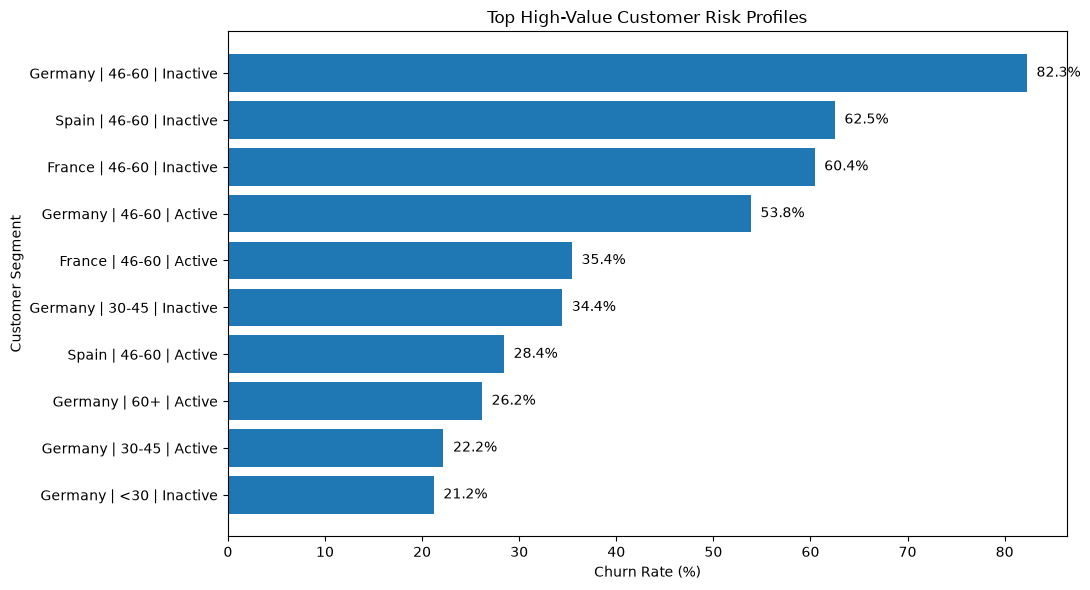

In [34]:
plt.figure(figsize=(11, 6))

plt.barh(
    top_hv_risk["Segment"],
    top_hv_risk["ChurnRate"]
)

plt.title(
    "Top High-Value Customer Risk Profiles"
)

plt.xlabel("Churn Rate (%)")
plt.ylabel("Customer Segment")

plt.gca().invert_yaxis()

for i, value in enumerate(
    top_hv_risk["ChurnRate"]
):
    plt.text(
        value + 1,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "../outputs/figures/top_high_value_risk_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:

import os


files = os.listdir("../outputs/figures")

for file in files:
    print("✅", file)

✅ high_value_churn_by_age.png
✅ high_value_churn_by_engagement.png
✅ high_value_churn_by_geography.png
✅ high_value_financial_exposure_by_geography.png
✅ top_high_value_risk_profiles.png


In [37]:
# Create output directory if it doesn't exist
import os

os.makedirs("../outputs/tables", exist_ok=True)

# Save High-Value Customer Analysis tables

hv_geo_churn.to_csv(
    "../outputs/tables/high_value_geography_churn.csv",
    index=False
)

hv_geo_exposure.to_csv(
    "../outputs/tables/high_value_geography_exposure.csv",
    index=False
)

hv_age_churn.to_csv(
    "../outputs/tables/high_value_age_churn.csv",
    index=False
)

hv_engagement_churn.to_csv(
    "../outputs/tables/high_value_engagement_churn.csv",
    index=False
)

hv_salary_balance.to_csv(
    "../outputs/tables/high_value_salary_balance.csv"
)

reliable_hv_risk_profile.to_csv(
    "../outputs/tables/high_value_risk_profiles.csv",
    index=False
)

print("✅ All Notebook 06 tables saved successfully!")

✅ All Notebook 06 tables saved successfully!
